In [3]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
!pip install grad-cam --quiet
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from collections import Counter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Official RAF-DB label mapping
label_map = {
    1: 'surprise', 2: 'fear', 3: 'disgust',
    4: 'happy', 5: 'sad', 6: 'anger', 7: 'neutral'
}
label_to_idx = {label: idx for idx, label in enumerate(label_map.values())}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}
NUM_CLASSES = len(label_to_idx)

DATA_ROOT = '/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET'

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using device: cuda


In [4]:
class RAFDBDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        for folder_num in os.listdir(root_dir):
            if not folder_num.isdigit():
                continue
            label_idx = label_to_idx[label_map[int(folder_num)]]
            folder_path = os.path.join(root_dir, folder_num)
            for fname in os.listdir(folder_path):
                self.samples.append((os.path.join(folder_path, fname), label_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [6]:
train_dataset = RAFDBDataset(os.path.join(DATA_ROOT, 'train'), transform=train_transform)
test_dataset = RAFDBDataset(os.path.join(DATA_ROOT, 'test'), transform=test_transform)

label_counts = Counter([label for _, label in train_dataset.samples])
print("Class distribution:", {idx_to_label[k]: v for k, v in sorted(label_counts.items())})

# Weighted sampler so minority classes (fear, disgust, anger) get seen more often per epoch
sample_weights = [1.0 / label_counts[label] for _, label in train_dataset.samples]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

Class distribution: {'surprise': 1290, 'fear': 281, 'disgust': 717, 'happy': 4772, 'sad': 1982, 'anger': 705, 'neutral': 2524}
Train: 12271, Test: 3068


In [7]:
model = models.mobilenet_v2(weights='IMAGENET1K_V1')
for param in model.parameters():
    param.requires_grad = False
model.classifier[1] = nn.Linear(model.last_channel, NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 103MB/s] 


In [8]:
num_epochs = 15
best_val_acc = 0.0

for epoch in range(num_epochs):
    start = time.time()

    # --- Train ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    # --- Validate ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    scheduler.step(val_loss)
    elapsed = time.time() - start

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"Time: {elapsed:.1f}s")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  → New best model saved (val_acc: {val_acc:.4f})")

print(f"\nHead-only training complete. Best val accuracy: {best_val_acc:.4f}")

Epoch 1/15 | Train Loss: 1.6510 Acc: 0.3683 | Val Loss: 1.5151 Acc: 0.4404 | Time: 86.2s
  → New best model saved (val_acc: 0.4404)
Epoch 2/15 | Train Loss: 1.5438 Acc: 0.4199 | Val Loss: 1.6902 Acc: 0.3618 | Time: 55.9s
Epoch 3/15 | Train Loss: 1.4863 Acc: 0.4473 | Val Loss: 1.4420 Acc: 0.4583 | Time: 51.0s
  → New best model saved (val_acc: 0.4583)
Epoch 4/15 | Train Loss: 1.4738 Acc: 0.4462 | Val Loss: 1.6216 Acc: 0.3983 | Time: 47.8s
Epoch 5/15 | Train Loss: 1.4582 Acc: 0.4507 | Val Loss: 1.4164 Acc: 0.4922 | Time: 46.4s
  → New best model saved (val_acc: 0.4922)
Epoch 6/15 | Train Loss: 1.4652 Acc: 0.4493 | Val Loss: 1.5168 Acc: 0.4302 | Time: 45.6s
Epoch 7/15 | Train Loss: 1.4587 Acc: 0.4555 | Val Loss: 1.4633 Acc: 0.4505 | Time: 44.6s
Epoch 8/15 | Train Loss: 1.4363 Acc: 0.4615 | Val Loss: 1.3764 Acc: 0.5072 | Time: 44.8s
  → New best model saved (val_acc: 0.5072)
Epoch 9/15 | Train Loss: 1.4549 Acc: 0.4568 | Val Loss: 1.5572 Acc: 0.4208 | Time: 45.2s
Epoch 10/15 | Train Loss: 1

In [9]:
model.load_state_dict(torch.load('best_model.pth'))

for name, param in model.named_parameters():
    if any(f'features.{i}.' in name for i in [16, 17, 18]) or 'classifier' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2)

num_epochs = 10
best_val_acc = 0.5020  # carry forward

for epoch in range(num_epochs):
    start = time.time()

    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    scheduler.step(val_loss)
    elapsed = time.time() - start

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"Time: {elapsed:.1f}s")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  → New best model saved (val_acc: {val_acc:.4f})")

print(f"\nFine-tuning complete. Best val accuracy: {best_val_acc:.4f}")

Epoch 1/10 | Train Loss: 1.3571 Acc: 0.4939 | Val Loss: 1.3987 Acc: 0.4840 | Time: 43.2s
Epoch 2/10 | Train Loss: 1.2799 Acc: 0.5281 | Val Loss: 1.3250 Acc: 0.5075 | Time: 42.2s
  → New best model saved (val_acc: 0.5075)
Epoch 3/10 | Train Loss: 1.2408 Acc: 0.5436 | Val Loss: 1.2969 Acc: 0.5244 | Time: 43.6s
  → New best model saved (val_acc: 0.5244)
Epoch 4/10 | Train Loss: 1.1719 Acc: 0.5640 | Val Loss: 1.2627 Acc: 0.5375 | Time: 43.3s
  → New best model saved (val_acc: 0.5375)
Epoch 5/10 | Train Loss: 1.1170 Acc: 0.5955 | Val Loss: 1.2079 Acc: 0.5567 | Time: 45.0s
  → New best model saved (val_acc: 0.5567)
Epoch 6/10 | Train Loss: 1.0839 Acc: 0.5996 | Val Loss: 1.1878 Acc: 0.5704 | Time: 43.9s
  → New best model saved (val_acc: 0.5704)
Epoch 7/10 | Train Loss: 1.0614 Acc: 0.6118 | Val Loss: 1.1663 Acc: 0.5753 | Time: 44.0s
  → New best model saved (val_acc: 0.5753)
Epoch 8/10 | Train Loss: 1.0226 Acc: 0.6253 | Val Loss: 1.1681 Acc: 0.5789 | Time: 43.5s
  → New best model saved (val_

In [10]:
model.load_state_dict(torch.load('best_model.pth'))

for name, param in model.named_parameters():
    if any(f'features.{i}.' in name for i in range(11, 19)) or 'classifier' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2)

num_epochs = 10
best_val_acc = 0.5988  # carry forward

for epoch in range(num_epochs):
    start = time.time()

    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    scheduler.step(val_loss)
    elapsed = time.time() - start

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"Time: {elapsed:.1f}s")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  → New best model saved (val_acc: {val_acc:.4f})")

print(f"\nFine-tuning complete. Best val accuracy: {best_val_acc:.4f}")

Epoch 1/10 | Train Loss: 0.9420 Acc: 0.6540 | Val Loss: 1.0669 Acc: 0.6170 | Time: 44.0s
  → New best model saved (val_acc: 0.6170)
Epoch 2/10 | Train Loss: 0.8447 Acc: 0.7004 | Val Loss: 1.0264 Acc: 0.6356 | Time: 44.4s
  → New best model saved (val_acc: 0.6356)
Epoch 3/10 | Train Loss: 0.7808 Acc: 0.7193 | Val Loss: 1.0069 Acc: 0.6392 | Time: 44.7s
  → New best model saved (val_acc: 0.6392)
Epoch 4/10 | Train Loss: 0.7418 Acc: 0.7353 | Val Loss: 0.9579 Acc: 0.6581 | Time: 44.4s
  → New best model saved (val_acc: 0.6581)
Epoch 5/10 | Train Loss: 0.6872 Acc: 0.7544 | Val Loss: 0.9234 Acc: 0.6701 | Time: 44.0s
  → New best model saved (val_acc: 0.6701)
Epoch 6/10 | Train Loss: 0.6351 Acc: 0.7747 | Val Loss: 0.9119 Acc: 0.6786 | Time: 44.0s
  → New best model saved (val_acc: 0.6786)
Epoch 7/10 | Train Loss: 0.6074 Acc: 0.7835 | Val Loss: 0.8848 Acc: 0.6848 | Time: 46.5s
  → New best model saved (val_acc: 0.6848)
Epoch 8/10 | Train Loss: 0.5607 Acc: 0.8011 | Val Loss: 0.9127 Acc: 0.6799 |

In [11]:
model.load_state_dict(torch.load('best_model.pth'))

for name, param in model.named_parameters():
    if any(f'features.{i}.' in name for i in range(11, 19)) or 'classifier' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2)

num_epochs = 10
best_val_acc = 0.7128 # carry forward

for epoch in range(num_epochs):
    start = time.time()

    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    scheduler.step(val_loss)
    elapsed = time.time() - start

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"Time: {elapsed:.1f}s")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  → New best model saved (val_acc: {val_acc:.4f})")

print(f"\nFine-tuning complete. Best val accuracy: {best_val_acc:.4f}")

Epoch 1/10 | Train Loss: 0.4657 Acc: 0.8402 | Val Loss: 0.8554 Acc: 0.7096 | Time: 44.5s
Epoch 2/10 | Train Loss: 0.4396 Acc: 0.8487 | Val Loss: 0.8368 Acc: 0.7099 | Time: 43.8s
Epoch 3/10 | Train Loss: 0.4250 Acc: 0.8516 | Val Loss: 0.8571 Acc: 0.7073 | Time: 43.4s
Epoch 4/10 | Train Loss: 0.4041 Acc: 0.8616 | Val Loss: 0.8331 Acc: 0.7138 | Time: 43.9s
  → New best model saved (val_acc: 0.7138)
Epoch 5/10 | Train Loss: 0.3832 Acc: 0.8677 | Val Loss: 0.8343 Acc: 0.7168 | Time: 43.6s
  → New best model saved (val_acc: 0.7168)
Epoch 6/10 | Train Loss: 0.3708 Acc: 0.8710 | Val Loss: 0.8234 Acc: 0.7236 | Time: 44.2s
  → New best model saved (val_acc: 0.7236)
Epoch 7/10 | Train Loss: 0.3325 Acc: 0.8850 | Val Loss: 0.8247 Acc: 0.7298 | Time: 43.4s
  → New best model saved (val_acc: 0.7298)
Epoch 8/10 | Train Loss: 0.3326 Acc: 0.8845 | Val Loss: 0.8271 Acc: 0.7265 | Time: 43.2s
Epoch 9/10 | Train Loss: 0.2909 Acc: 0.9047 | Val Loss: 0.8332 Acc: 0.7203 | Time: 43.6s
Epoch 10/10 | Train Loss: 0

              precision    recall  f1-score   support

    surprise       0.69      0.83      0.75       329
        fear       0.59      0.51      0.55        74
     disgust       0.36      0.49      0.42       160
       happy       0.90      0.81      0.86      1185
         sad       0.66      0.65      0.65       478
       anger       0.63      0.67      0.65       162
     neutral       0.69      0.69      0.69       680

    accuracy                           0.73      3068
   macro avg       0.65      0.66      0.65      3068
weighted avg       0.74      0.73      0.73      3068



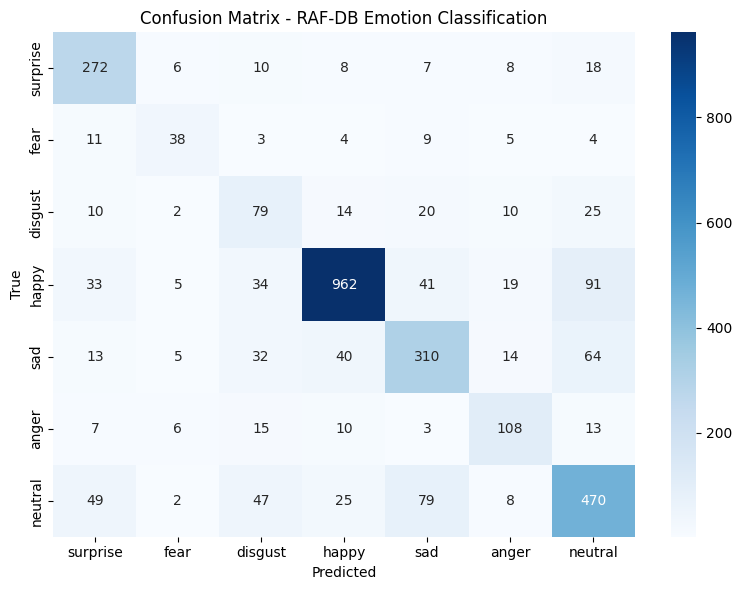

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Load best model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = [idx_to_label[i] for i in range(7)]

# Classification report (precision/recall/F1 per class)
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - RAF-DB Emotion Classification')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

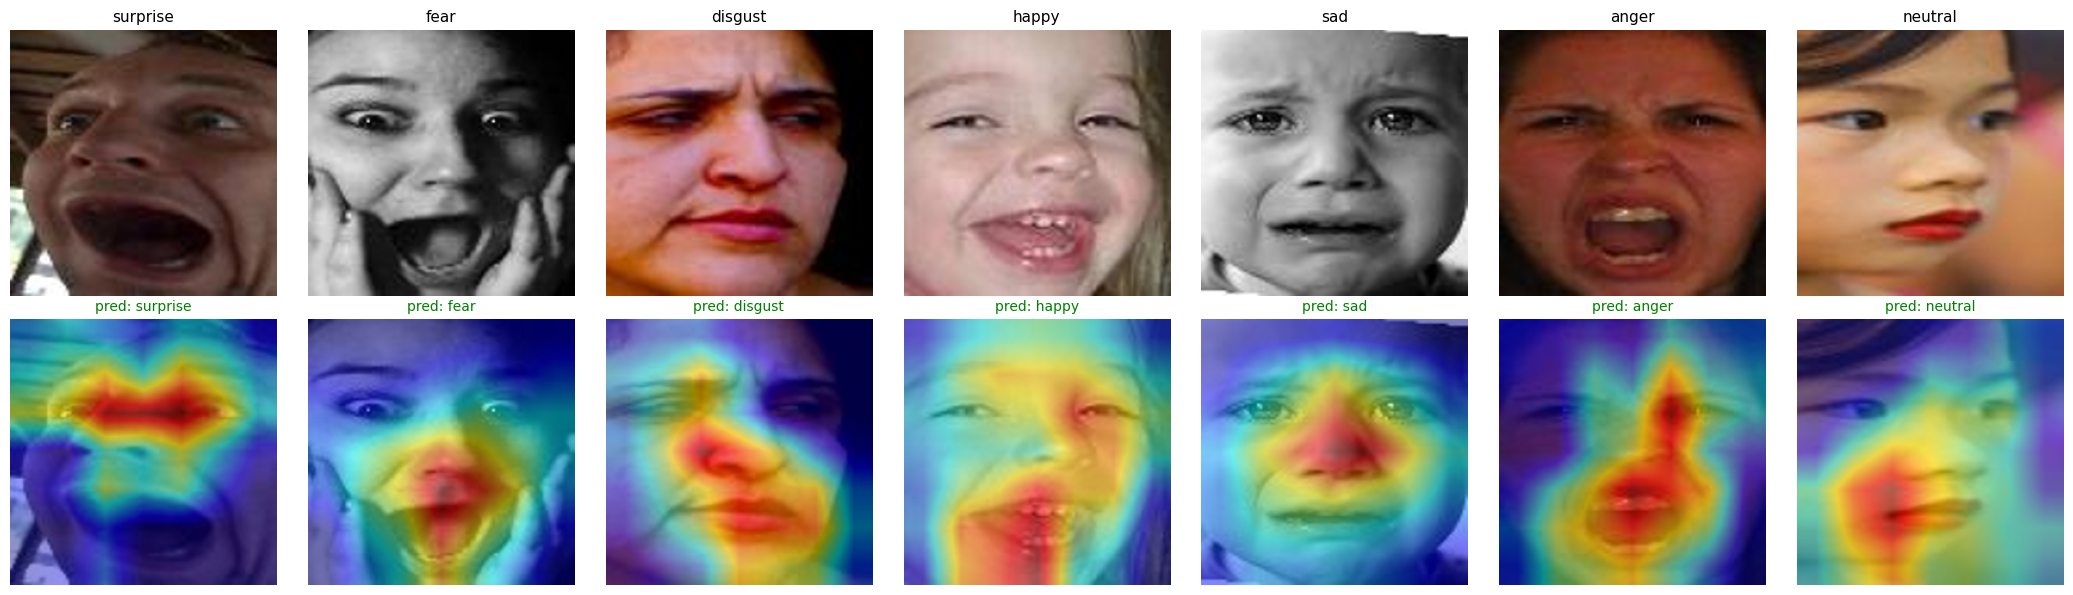

In [14]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# MobileNetV2's last conv block — good target layer for Grad-CAM
target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# Find one correctly-classified example per class (falls back to any example if none found)
examples = {}
for img_path, label in test_dataset.samples:
    if label in examples:
        continue
    with torch.no_grad():
        img = Image.open(img_path).convert('RGB')
        tensor = test_transform(img).unsqueeze(0).to(device)
        pred = model(tensor).argmax(dim=1).item()
    if pred == label:
        examples[label] = (img_path, label)
    if len(examples) == NUM_CLASSES:
        break

# good enough for a presentation figure, not meant to be exhaustive search
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(3 * NUM_CLASSES, 6))

for idx in range(NUM_CLASSES):
    img_path, label = examples[idx]
    img = Image.open(img_path).convert('RGB').resize((224, 224))
    rgb_img = np.array(img).astype(np.float32) / 255.0

    input_tensor = test_transform(Image.open(img_path).convert('RGB')).unsqueeze(0).to(device)
    with torch.no_grad():
        pred_idx = model(input_tensor).argmax(dim=1).item()

    targets = [ClassifierOutputTarget(pred_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    axes[0, idx].imshow(rgb_img)
    axes[0, idx].set_title(idx_to_label[label], fontsize=11)
    axes[0, idx].axis('off')

    axes[1, idx].imshow(visualization)
    pred_label = idx_to_label[pred_idx]
    color = 'green' if pred_idx == label else 'red'
    axes[1, idx].set_title(f'pred: {pred_label}', fontsize=10, color=color)
    axes[1, idx].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=12)
axes[1, 0].set_ylabel('Grad-CAM', fontsize=12)

plt.tight_layout()
plt.savefig('gradcam_grid.png', dpi=150, bbox_inches='tight')
plt.show()